# Day 6 - Advanced Analytics & Risk  Metrics

## Section 1: Historical Value at Risk (VaR) and Conditional Valur at Risk (CVaR)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
nav_path = Path('../data/processed/clean_nav_history.csv')
nav_df = pd.read_csv(nav_path)

print(nav_df.shape)
nav_df.head()

(64320, 3)


,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


In [3]:
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])

nav_df['daily_return'] = (nav_df.groupby('amfi_code')['nav'].pct_change())

returns_df = nav_df.dropna(subset=['daily_return']).copy()
print(returns_df.shape)
returns_df.head()

(64280, 4)


,date,amfi_code,nav,daily_return
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210
5,2022-01-08,100016,515.1639,0.000000


In [4]:
returns_df["daily_return"].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

In [5]:
var_cvar_results = []

for fund_code, group in returns_df.groupby('amfi_code'):
   returns = group['daily_return']

   var_95 = np.percentile(returns, 5)
   cvar_95 = returns[returns <= var_95].mean()

   var_cvar_results.append({
      'amfi_code': fund_code,
      'VaR_95': var_95,
      'CVaR_95': cvar_95
   })

var_cvar_df = pd.DataFrame(var_cvar_results)
var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.012884,-0.016768
1,100025,-0.003338,-0.004581
2,100033,-0.016902,-0.021850
3,101206,-0.012173,-0.016075
4,101207,-0.023915,-0.030289


In [6]:
var_cvar_df.sort_values('VaR_95').head(10)

,amfi_code,VaR_95,CVaR_95
4,101207,-0.023915,-0.030289
17,119095,-0.023284,-0.029690
22,119599,-0.023155,-0.030163
11,118634,-0.022810,-0.029940
39,149324,-0.021520,-0.028573
21,119598,-0.021502,-0.028444
16,119094,-0.016997,-0.022375
29,120842,-0.016950,-0.021251
2,100033,-0.016902,-0.021850
7,102886,-0.016857,-0.021771


In [7]:
fund_master = pd.read_csv('../data/raw/01_fund_master.csv')

var_cvar_df = var_cvar_df.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.012884,-0.016768,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003338,-0.004581,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.016902,-0.021850,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.012173,-0.016075,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.023915,-0.030289,ABSL Small Cap Fund - Regular - Growth


In [8]:
var_cvar_df = var_cvar_df.sort_values('VaR_95')

var_cvar_df.to_csv(
    '../data/processed/var_cvar_report.csv',
    index=False
)

print('var_cvar_report.csv saved successfully')

var_cvar_report.csv saved successfully


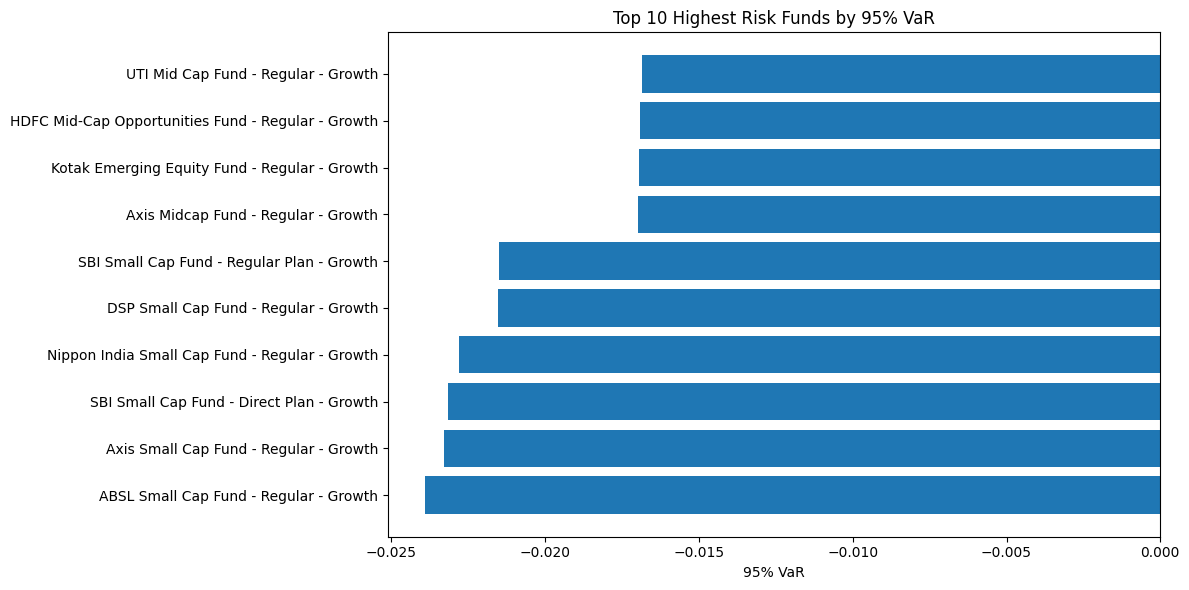

In [9]:
top10_risk = var_cvar_df.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10_risk['scheme_name'],
    top10_risk['VaR_95']
)

plt.title('Top 10 Highest Risk Funds by 95% VaR')
plt.xlabel('95% VaR')
plt.tight_layout()

plt.show()

### Insight 1

The highest-risk mutual funds exhibited 95% Value-at-Risk levels exceeding 2% per day, indicating greater downside exposure under adverse market conditions. Conditional VaR values were consistently lower than VaR thresholds, suggesting that losses become significantly more severe once extreme downside events occur.

In [10]:
sharpe_df = pd.read_csv('../data/processed/sharpe_values.csv')
sharpe_df.sort_values('sharpe_ratio', ascending=False).head()

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.161096,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.034602,Kotak Flexicap Fund - Regular - Growth
36,148569,0.974332,Mirae Asset Tax Saver Fund - Regular - Growth
25,120505,0.926797,ICICI Pru Midcap Fund - Regular - Growth
19,119551,0.916203,SBI Bluechip Fund - Regular Plan - Growth


In [11]:
top5_funds = [
    148567,
    120843,
    148569,
    120505,
    119551
]

top5_funds

[148567, 120843, 148569, 120505, 119551]

In [12]:
rolling_sharpe_data = []

for fund in top5_funds:
   fund_data = returns_df[returns_df['amfi_code'] == fund].copy()

   fund_data['rolling_sharpe'] = (
      fund_data['daily_return']
      .rolling(90)
      .mean()
      /
      fund_data['daily_return']
      .rolling(90)
      .std()
   ) * np.sqrt(252)

   rolling_sharpe_data.append(fund_data)

rolling_sharpe_df = pd.concat(
    rolling_sharpe_data,
    ignore_index=True
)

rolling_sharpe_df.head()

,date,amfi_code,nav,daily_return,rolling_sharpe
0,2022-01-04,148567,71.6085,0.019318,NaN
1,2022-01-05,148567,71.3264,-0.003939,NaN
2,2022-01-06,148567,72.1746,0.011892,NaN
3,2022-01-07,148567,72.2118,0.000515,NaN
4,2022-01-08,148567,72.2118,0.000000,NaN


In [13]:
rolling_sharpe_df[
    ['amfi_code', 'date', 'rolling_sharpe']
].tail()

,amfi_code,date,rolling_sharpe
8030,119551,2026-05-25,4.879228
8031,119551,2026-05-26,4.655972
8032,119551,2026-05-27,3.933834
8033,119551,2026-05-28,4.128076
8034,119551,2026-05-29,3.928751


In [14]:
rolling_sharpe_df = rolling_sharpe_df.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

rolling_sharpe_df.head()

,date,amfi_code,nav,daily_return,rolling_sharpe,scheme_name
0,2022-01-04,148567,71.6085,0.019318,NaN,Mirae Asset Large Cap Fund - Regular - Growth
1,2022-01-05,148567,71.3264,-0.003939,NaN,Mirae Asset Large Cap Fund - Regular - Growth
2,2022-01-06,148567,72.1746,0.011892,NaN,Mirae Asset Large Cap Fund - Regular - Growth
3,2022-01-07,148567,72.2118,0.000515,NaN,Mirae Asset Large Cap Fund - Regular - Growth
4,2022-01-08,148567,72.2118,0.000000,NaN,Mirae Asset Large Cap Fund - Regular - Growth


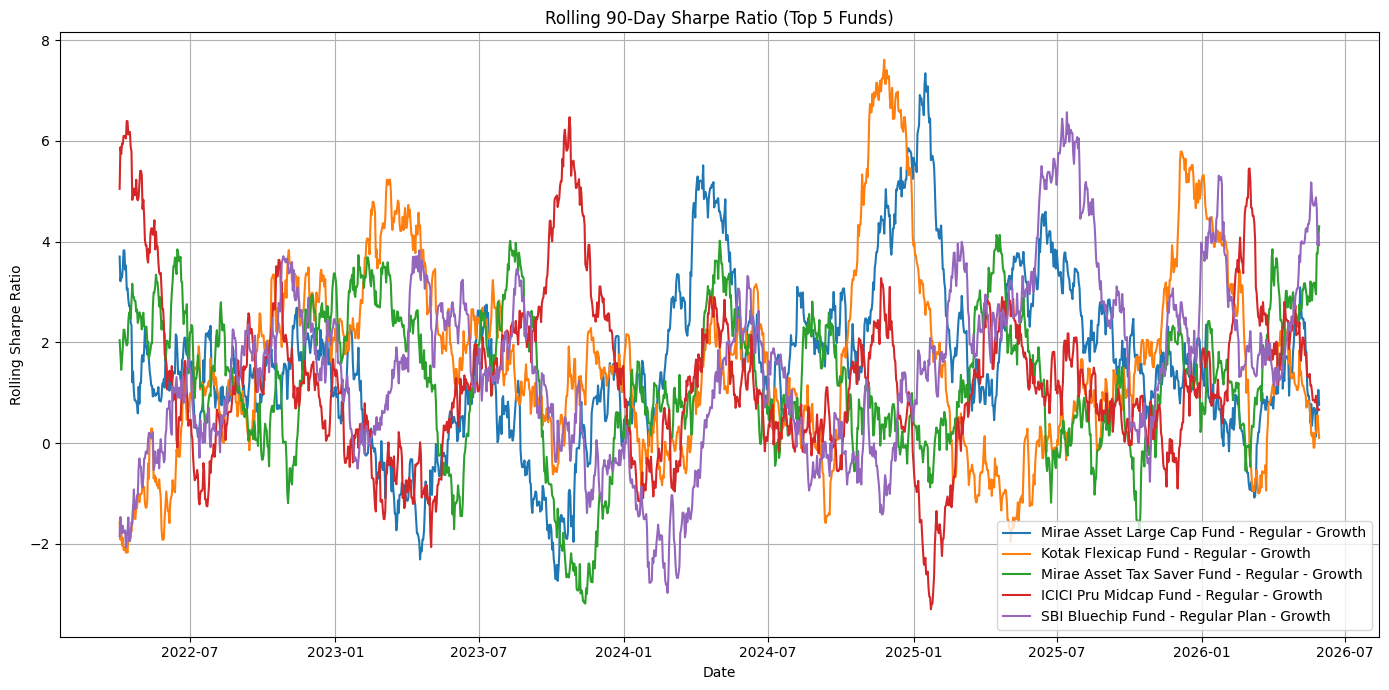

In [15]:
plt.figure(figsize=(14,7))

for fund in top5_funds:
   fund_data = rolling_sharpe_df[rolling_sharpe_df['amfi_code'] == fund]
   fund_name = fund_data['scheme_name'].iloc[0]

   plt.plot(
      fund_data['date'],
      fund_data['rolling_sharpe'],
      label=fund_name
   )

plt.title('Rolling 90-Day Sharpe Ratio (Top 5 Funds)')
plt.xlabel('Date')
plt.ylabel('Rolling Sharpe Ratio')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    '../reports/rolling_sharpe_chart.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insight 2

Rolling 90-day Sharpe Ratios varied significantly across time, indicating changing risk-adjusted performance under different market environments. The highest-ranked funds maintained consistently positive Sharpe Ratios for extended periods, demonstrating superior risk-adjusted returns relative to peers.

In [16]:
transactions_df = pd.read_csv(
    '../data/processed/clean_investor_transactions.csv'
)

transactions_df.shape

(32778, 13)

In [17]:
transactions_df['transaction_date'] = pd.to_datetime(transactions_df['transaction_date'])

first_tx = (
   transactions_df
   .groupby('investor_id')['transaction_date']
   .min()
   .reset_index()
)

first_tx['cohort_year'] = (first_tx['transaction_date'].dt.year)

first_tx.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [18]:
transactions_df = transactions_df.merge(
   first_tx[['investor_id', 'cohort_year']],
   on='investor_id',
   how='left'
)

transactions_df[['investor_id', 'cohort_year']].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [19]:
sip_df = transactions_df[transactions_df['transaction_type'] == 'SIP'].copy()

print(sip_df.shape)

(19716, 14)


In [20]:
cohort_analysis = (
   sip_df.groupby('cohort_year').agg(
      investor_count=('investor_id', 'nunique'),
      avg_sip_amount=('amount_inr', 'mean'),
      total_invested=('amount_inr', 'sum')
   ).reset_index()
)

cohort_analysis

,cohort_year,investor_count,avg_sip_amount,total_invested
0,2024,4624,10996.885825,214978121
1,2025,138,13505.209581,2255370


In [21]:
cohort_fund_pref = (
   sip_df
   .groupby(
      ['cohort_year', 'amfi_code']
   )
   .size()
   .reset_index(name='transaction_count')
)

cohort_fund_pref.head()

,cohort_year,amfi_code,transaction_count
0,2024,100016,512
1,2024,100025,447
2,2024,100033,440
3,2024,101206,485
4,2024,101207,532


In [22]:
top_funds_by_cohort = (
   cohort_fund_pref.sort_values(
      ['cohort_year', 'transaction_count'],
      ascending=[True, False]
   ).groupby('cohort_year').head(3)
)

top_funds_by_cohort

,cohort_year,amfi_code,transaction_count
24,2024,120504,536
33,2024,125498,534
4,2024,101207,532
62,2025,119599,8
49,2025,118632,7
52,2025,118635,7


In [23]:
top_funds_by_cohort = top_funds_by_cohort.merge(
   fund_master[['amfi_code', 'scheme_name']],
   on='amfi_code',
   how='left'
)

top_funds_by_cohort[
   [
      'cohort_year',
      'scheme_name',
      'transaction_count'
   ]
]

,cohort_year,scheme_name,transaction_count
0,2024,ICICI Pru Bluechip Fund - Direct - Growth,536
1,2024,HDFC Mid-Cap Opportunities Fund - Direct - Growth,534
2,2024,ABSL Small Cap Fund - Regular - Growth,532
3,2025,SBI Small Cap Fund - Direct Plan - Growth,8
4,2025,Nippon India Large Cap Fund - Regular - Growth,7
5,2025,Nippon India ETF Nifty 50 BeES,7


In [24]:
cohort_analysis.to_csv('../data/processed/cohort_analysis.csv', index=False)

print('cohort_analysis.csv saved successfully')

cohort_analysis.csv saved successfully


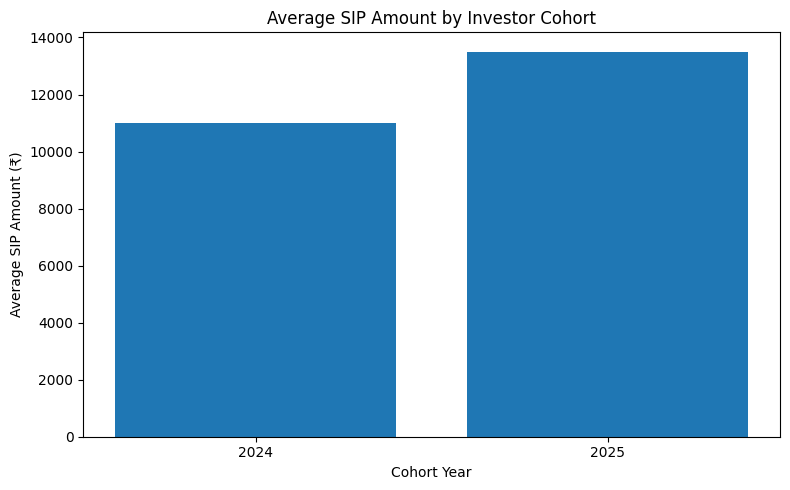

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
   cohort_analysis['cohort_year'].astype(str),
   cohort_analysis['avg_sip_amount']
)

plt.title('Average SIP Amount by Investor Cohort')
plt.xlabel('Cohort Year')
plt.ylabel('Average SIP Amount (₹)')

plt.tight_layout()
plt.show()

### Insight 3

Investor cohort analysis revealed that investors entering in 2025 contributed larger average SIP amounts than those entering in 2024. However, the 2024 cohort accounted for the overwhelming majority of investors and total invested capital, indicating a more mature and established investor base.

In [26]:
sip_counts = (
   sip_df
   .groupby('investor_id')
   .size()
   .reset_index(name='sip_count')
)

sip_counts.sort_values('sip_count', ascending=False).head()

,investor_id,sip_count
3962,INV004154,12
586,INV000612,11
4223,INV004427,11
1597,INV001673,11
649,INV000676,11


In [27]:
eligible_investors = sip_counts[sip_counts['sip_count'] >= 6]

print(f'Eligible investors: {eligible_investors.shape[0]}')

Eligible investors: 1362


In [28]:
eligible_sip_df = sip_df[
   sip_df['investor_id'].isin(
      eligible_investors['investor_id']
   )
].copy()

eligible_sip_df.shape

(9679, 14)

In [29]:
eligible_sip_df = eligible_sip_df.sort_values(['investor_id', 'transaction_date'])

eligible_sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024


In [30]:
eligible_sip_df['gap_days'] = (
   eligible_sip_df
   .groupby('investor_id')['transaction_date']
   .diff()
   .dt.days
)

eligible_sip_df[
   [
      'investor_id',
      'transaction_date',
      'gap_days'
   ]
].head(15)

,investor_id,transaction_date,gap_days
4773,INV000004,2024-03-16,NaN
6418,INV000004,2024-04-11,26.0
8271,INV000004,2024-05-09,28.0
12003,INV000004,2024-07-07,59.0
28749,INV000004,2025-03-29,265.0
31897,INV000004,2025-05-17,49.0
9329,INV000008,2024-05-27,NaN
11113,INV000008,2024-06-23,27.0
21549,INV000008,2024-12-05,165.0
24389,INV000008,2025-01-18,44.0


In [31]:
sip_continuity = (
   eligible_sip_df
   .groupby('investor_id')
   .agg(
      avg_gap_days=('gap_days', 'mean')
   )
   .reset_index()
)

sip_tx_count = (
   eligible_sip_df
   .groupby('investor_id')
   .size()
   .reset_index(name='sip_count')
)

sip_continuity = sip_continuity.merge(
   sip_tx_count,
   on='investor_id',
   how='left'
)

sip_continuity.head()

,investor_id,avg_gap_days,sip_count
0,INV000004,85.400000,6
1,INV000008,70.400000,6
2,INV000010,64.800000,6
3,INV000011,40.166667,7
4,INV000012,57.000000,8


In [32]:
sip_continuity['at_risk'] = (sip_continuity['avg_gap_days'] > 35)

sip_continuity.head()

,investor_id,avg_gap_days,sip_count,at_risk
0,INV000004,85.400000,6,True
1,INV000008,70.400000,6,True
2,INV000010,64.800000,6,True
3,INV000011,40.166667,7,True
4,INV000012,57.000000,8,True


In [33]:
sip_continuity['at_risk'].value_counts()

at_risk
True     1332
False      30
Name: count, dtype: int64

In [34]:
sip_continuity.to_csv(
   '../data/processed/sip_continuity.csv',
   index=False
)

print('sip_continuity.csv saved successfully')

sip_continuity.csv saved successfully


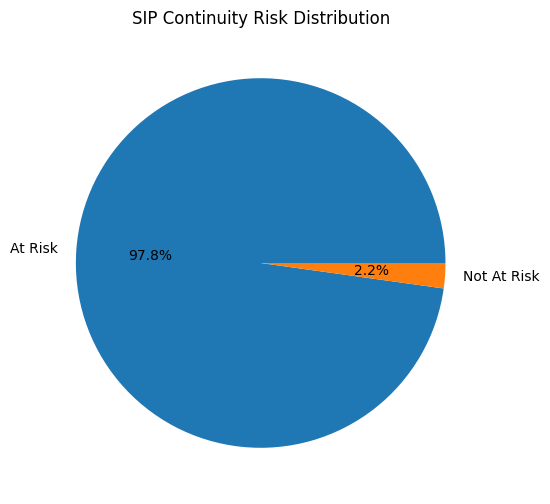

In [35]:
risk_counts = (sip_continuity['at_risk'].value_counts())

plt.figure(figsize=(6,6))
plt.pie(
   risk_counts,
   labels=['At Risk', 'Not At Risk'],
   autopct='%1.1f%%'
)

plt.title('SIP Continuity Risk Distribution')
plt.show()

### Insight 4

Using a 35-day continuity threshold, the majority of eligible SIP investors were classified as at-risk. This suggests that many investors exhibit irregular contribution patterns, highlighting the importance of investor engagement and retention initiatives.

In [36]:
recommender_df = sharpe_df.merge(
   fund_master[
      ['amfi_code', 'scheme_name', 'risk_category']
   ],
   on=['amfi_code', 'scheme_name'],
   how='left'
)

recommender_df.head()

,amfi_code,sharpe_ratio,scheme_name,risk_category
0,100016,-0.381120,HDFC Top 100 Fund - Regular Plan - Growth,Moderate
1,100025,-1.042660,HDFC Short Term Debt Fund - Regular - Growth,Low
2,100033,0.837330,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
3,101206,0.746112,ABSL Frontline Equity Fund - Regular - Growth,Moderate
4,101207,-0.049875,ABSL Small Cap Fund - Regular - Growth,Very High


In [37]:
risk_mapping = {
    'Low': ['Low', 'Moderate'],
    'Moderate': ['Moderate', 'Moderately High'],
    'High': ['High', 'Very High']
}

In [38]:
def recommend_funds(user_risk):
   eligible_risks = risk_mapping[user_risk]

   recommendations = (
      recommender_df[
         recommender_df['risk_category']
         .isin(eligible_risks)
      ]
      .sort_values(
         'sharpe_ratio',
         ascending=False
      )
      .head(3)
   )

   return recommendations[
      [
         'scheme_name',
         'risk_category',
         'sharpe_ratio'
      ]
   ]

In [39]:
print('LOW RISK')
display(recommend_funds('Low'))

print('MODERATE RISK')
display(recommend_funds('Moderate'))

print('HIGH RISK')
display(recommend_funds('High'))

LOW RISK


,scheme_name,risk_category,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.161096
19,SBI Bluechip Fund - Regular Plan - Growth,Moderate,0.916203
9,Nippon India Large Cap Fund - Regular - Growth,Moderate,0.795720


MODERATE RISK


,scheme_name,risk_category,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.161096
30,Kotak Flexicap Fund - Regular - Growth,Moderately High,1.034602
19,SBI Bluechip Fund - Regular Plan - Growth,Moderate,0.916203


HIGH RISK


,scheme_name,risk_category,sharpe_ratio
36,Mirae Asset Tax Saver Fund - Regular - Growth,High,0.974332
25,ICICI Pru Midcap Fund - Regular - Growth,High,0.926797
38,DSP Midcap Fund - Regular - Growth,High,0.870455


### Insight 5

The recommendation engine successfully mapped investor risk appetite to suitable mutual fund schemes and ranked them using Sharpe Ratio. This enables a simple risk-adjusted fund selection framework that can be extended into a personalized investment advisory tool.

In [40]:
portfolio_df = pd.read_csv('../data/raw/09_portfolio_holdings.csv')

portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [41]:
sector_hhi = (
   portfolio_df.groupby('amfi_code').apply(
      lambda x: (x['weight_pct'] ** 2).sum()
   ).reset_index(name='hhi_score')
)

sector_hhi.head()

,amfi_code,hhi_score
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902


In [42]:
sector_hhi = sector_hhi.merge(
   fund_master[['amfi_code', 'scheme_name']],
   on='amfi_code',
   how='left'
)

sector_hhi.head()

,amfi_code,hhi_score,scheme_name
0,100016,1395.3386,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,1475.9226,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,1293.3173,ABSL Frontline Equity Fund - Regular - Growth
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth


In [43]:
sector_hhi.sort_values('hhi_score', ascending=False).head(10)

,amfi_code,hhi_score,scheme_name
11,119092,2064.4767,Axis Bluechip Fund - Regular - Growth
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth
18,119599,1747.5096,SBI Small Cap Fund - Direct Plan - Growth
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,1682.9820,Nippon India Large Cap Fund - Regular - Growth
29,148568,1679.2973,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,1575.7036,ICICI Pru Midcap Fund - Regular - Growth
22,120506,1537.9360,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,1524.1398,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,1496.8035,Kotak Bluechip Fund - Regular - Growth


In [44]:
sector_hhi.to_csv(
   '../data/processed/sector_hhi.csv',
   index=False
)

print('sector_hhi.csv saved successfully')

sector_hhi.csv saved successfully


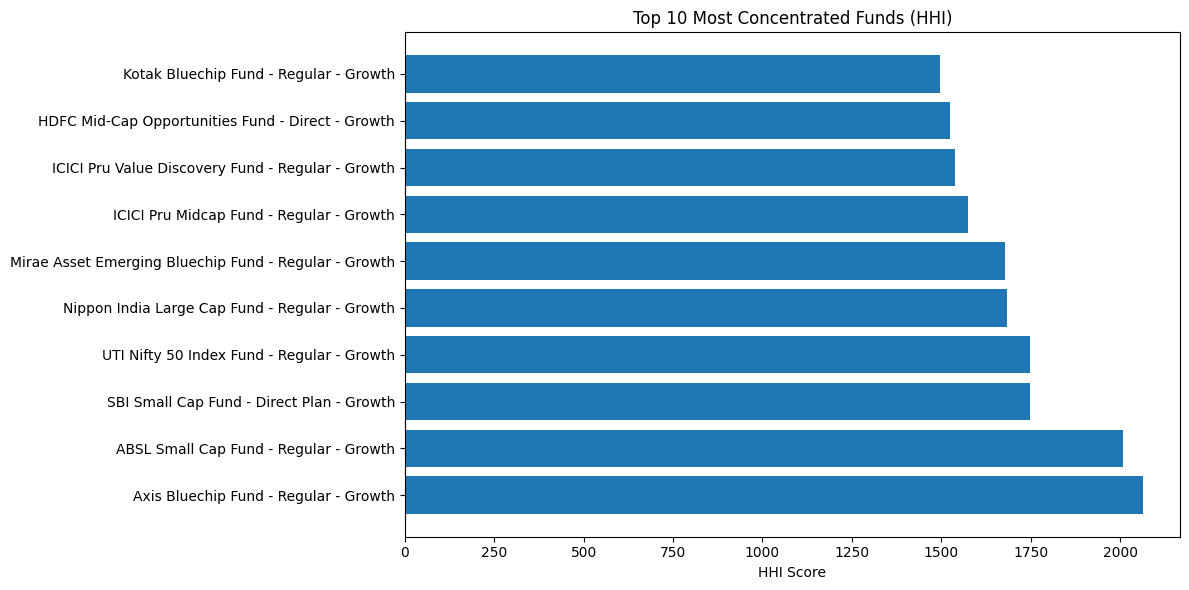

In [45]:
top_hhi = (
   sector_hhi.sort_values(
      'hhi_score',
      ascending=False
   ).head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
   top_hhi['scheme_name'],
   top_hhi['hhi_score']
)

plt.title('Top 10 Most Concentrated Funds (HHI)')
plt.xlabel('HHI Score')

plt.tight_layout()
plt.show()

### Insight 6

Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) revealed meaningful differences in diversification across mutual fund schemes. Several funds exhibited moderate concentration levels, indicating higher exposure to a limited set of sectors, while others demonstrated more diversified portfolio construction.